# Imports

In [2]:
from controller import Controller
from eom import EOM
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_are

# Set up EOM

In [3]:
eom = EOM()

# Params
mass = 0.5  # kg
inertia = np.diag([0.0023, 0.0023, 0.0040])  # kg*m^2
leg_length = 0.175  # m
k_f_val = 62.8 # Slope of thrust/motor torque curve (linear)
k_yaw_val = 1.0 # Yaw torque constant, default 1.0

eom.set_parameters(mass, inertia, leg_length, k_f_val, k_yaw_val)
eom.setup()

# Define LQR function

In [4]:
def lqr(A: np.ndarray, B: np.ndarray, Q: np.ndarray, R: np.ndarray) -> np.ndarray:
    """Compute the LQR gain matrix K.

    Args:
        A (np.ndarray): State matrix.
        B (np.ndarray): Input matrix.
        Q (np.ndarray): State cost matrix.
        R (np.ndarray): Input cost matrix.

    Returns:
        np.ndarray: LQR gain matrix K.
    """
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ B.T @ P
    return K

# Create controller object

In [5]:
# Params
dt = 0.0005  # time step, s
t_max = 10.0 # total simulation time, s
max_motor_torque = 0.0851209 # N*m
x0 = np.zeros(12)  # initial state
u0 = np.array([eom.tau_e, eom.tau_e, eom.tau_e, eom.tau_e])  # initial input (hover)

controller = Controller(eom=eom, dt=dt, t_max=t_max, max_motor_torque=max_motor_torque, x0=x0, u0=u0)

# Define gain matrix K

In [6]:
# position (p_x, p_y, p_z)
q_pos = 2.0 * 1e0
# angles (psi, theta, phi)
q_ang = 1.0 * 1e-2
# linear velocities (v_x, v_y, v_z)
q_vel = 2.0 * 1e0
# angular velocities (w_x, w_y, w_z)
q_omega = 1.0 * 1e-2

Q = np.diag([
    q_pos, q_pos, q_pos,      # p_x, p_y, p_z
    q_ang, q_ang, q_ang,      # psi, theta, phi
    q_vel, q_vel, q_vel,      # v_x, v_y, v_z
    q_omega, q_omega, q_omega # w_x, w_y, w_z
])

R = 1e-4 * np.eye(4)  # penalize large motor deviations a bit
K = lqr(eom.A_num, eom.B_num, Q, R)
controller.setK(K)


# Performance Goal 1: Hover at 1 meter

## Control loop

In [7]:
# Hover 1m above ground for 2 minutes
t = 0.0
t_max = 150
x = x0
x_des_land = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_des_hov = np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # desired state: hover at 1 meter
while t < t_max-10:
    controller.step(t, x, x_des_hov)
    t += dt
    x = controller.states[-1]
    # print(controller.inputs[-1])
while t < t_max:
    controller.step(t, x, x_des_land)
    t += dt
    x = controller.states[-1]
    # print(controller.inputs[-1])

## Plots

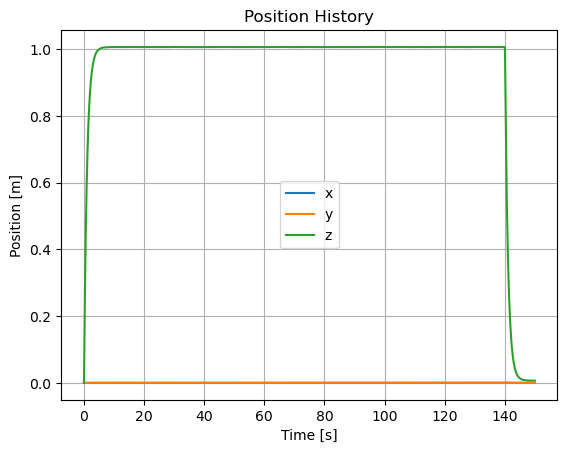

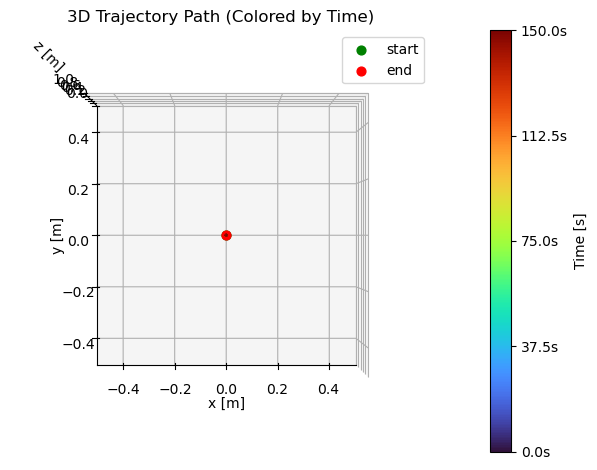

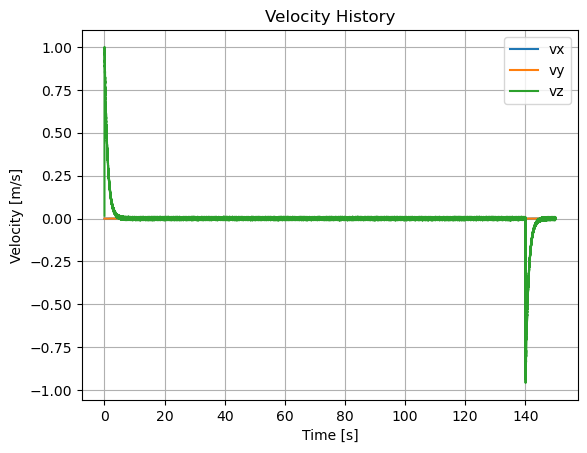

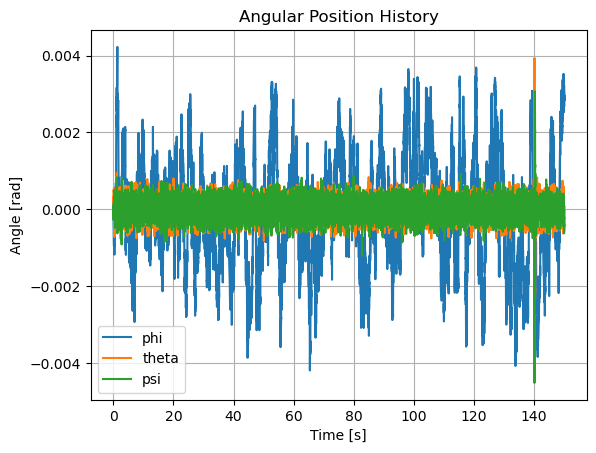

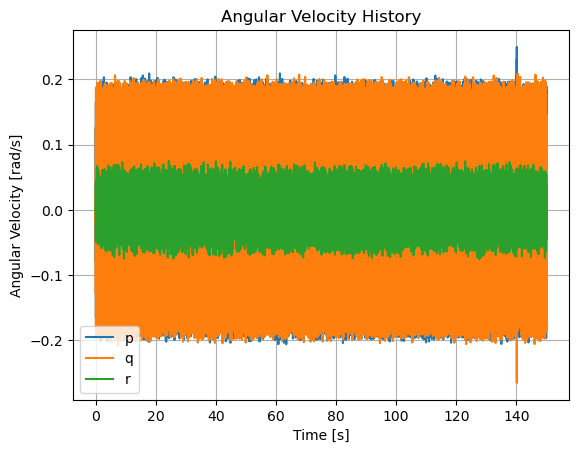

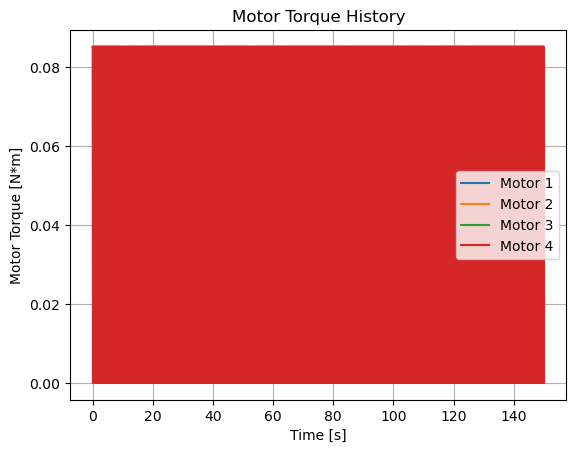

In [8]:
controller.plot_all()

# Performance Goal 2: Circular motion

In [13]:
# Fly in a circle of radius 2m, at an altitude of 1m above ground at a speed of 0.5m/s for at least 1 minute.
controller = Controller(eom=eom, dt=dt, t_max=t_max, max_motor_torque=max_motor_torque, x0=x0, u0=u0)
controller.setK(K)
t = 0.0
t_max = 80 # 10s to get to behind start, 10s to accel, 60s to circle, 10s to land
x = x0
x_des_start = np.array([2.0, -1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # desired state: circle start
while t < 10.0:
    controller.step(t, x, x_des_start)
    t += dt
    x = controller.states[-1]
x_des_circ = np.array([2.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0])
tstart = 0.0
while np.linalg.norm(x[0:3] - x_des_circ[0:3]) > .1: # end up at (2,0,1) at 0.5m/s
    controller.step(t, x, x_des_circ)
    t += dt
    x = controller.states[-1]
    tstart = t
while t < tstart + 61.0:
    theta = .25*(t-tstart) # dtheta = .5/2 = .25
    px, py = 2*np.cos(theta), 2*np.sin(theta)
    vx, vy = -0.5*np.sin(theta), 0.5*np.cos(theta)
    x_des_circ[0] = px
    x_des_circ[1] = py
    x_des_circ[6] = vx
    x_des_circ[7] = vy
    controller.step(t, x, x_des_circ)
    t += dt
    x = controller.states[-1]
while t < t_max:
    controller.step(t, x, x_des_land)
    t += dt
    x = controller.states[-1]

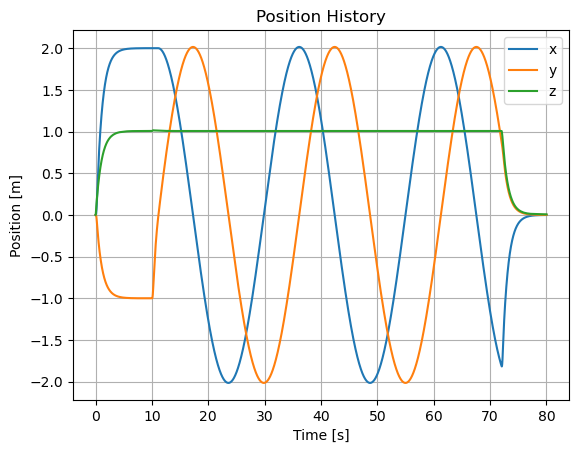

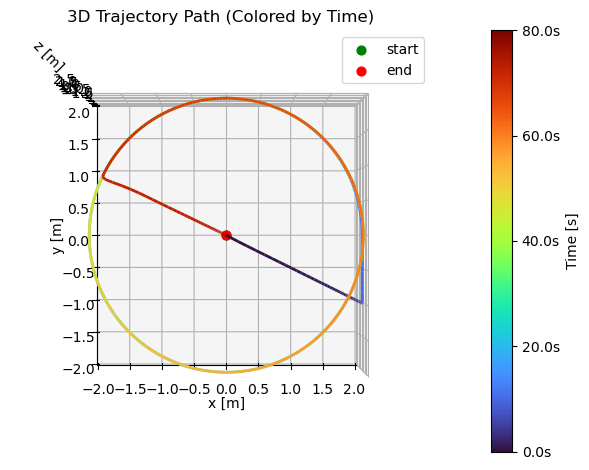

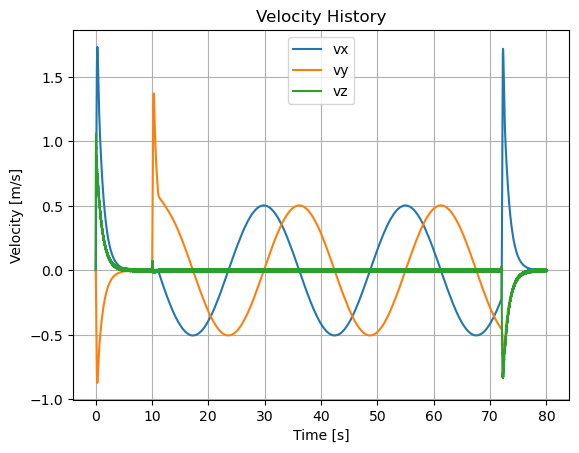

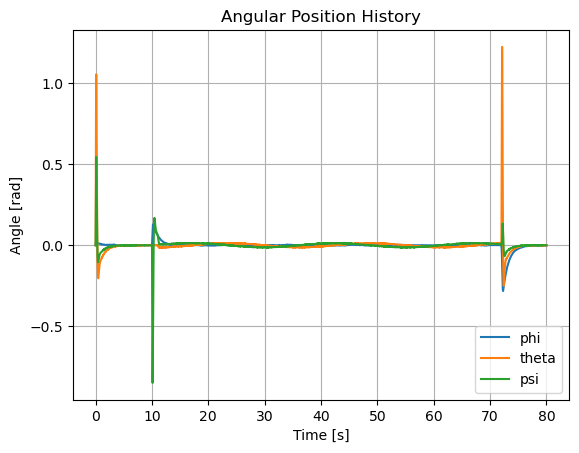

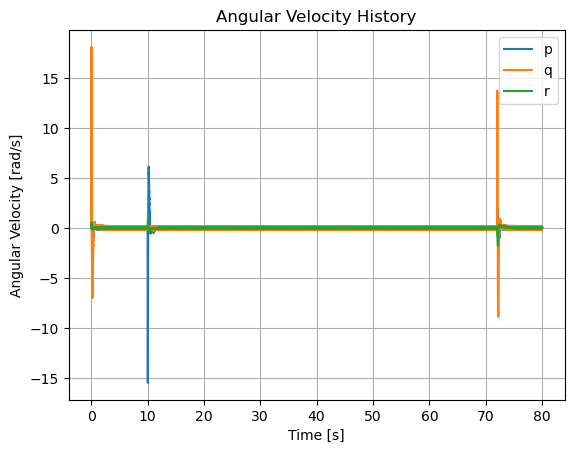

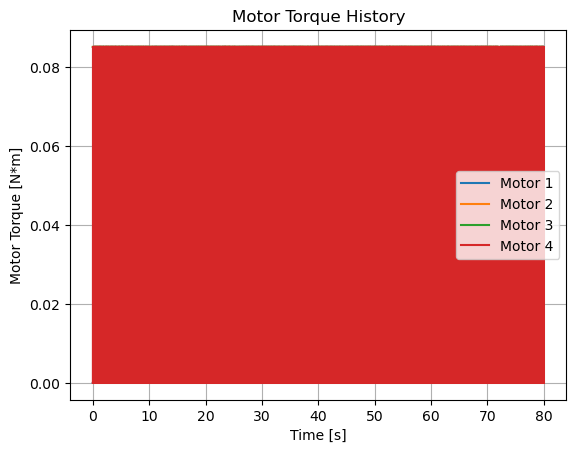

In [14]:
# Plot
controller.plot_all()

In [20]:
controller = Controller(eom=eom, dt=dt, t_max=t_max,
                        max_motor_torque=max_motor_torque,
                        x0=x0, u0=u0)
controller.setK(K)

t = 0.0
t_max = 60.0
x = x0.copy()

# 12D desired state
x_des = np.zeros(12)

# -----------------------
# 1) ASCENT TO z = 1 m
# -----------------------
# Vertical line at (x,y) = (0,0), from z0 to z=1.0
px0, py0, z0 = 0.0, 0.0, x[2]
z1 = 1.0
Dz = z1 - z0
v_up = 0.3                 # climb speed [m/s]
T_up = Dz / v_up           # segment duration

t0 = t
while t < t0 + T_up:
    s = (t - t0) / T_up    # in [0,1]
    z_des = z0 + s * Dz
    vz_des = v_up

    x_des[:] = 0.0
    x_des[0] = px0
    x_des[1] = py0
    x_des[2] = z_des
    x_des[8] = vz_des      # vz

    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# Optional hover at (0,0,1)
hover_time = 2.0
t0 = t
x_des[:] = 0.0
x_des[0] = 0.0
x_des[1] = 0.0
x_des[2] = 1.0
while t < t0 + hover_time:
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# -----------------------
# 2) FIRST 5 m LEG ALONG +x, 1 m/s
# -----------------------
# From (0,0,1) -> (5,0,1)
p0 = np.array([0.0, 0.0, 1.0])
p1 = np.array([5.0, 0.0, 1.0])
D1 = 5.0
v_leg = 1.0                # average speed
T1 = D1 / v_leg            # = 5 s

t0 = t
while t < t0 + T1:
    s = (t - t0) / T1
    p_des = p0 + s * (p1 - p0)
    v_des = (p1 - p0) / T1   # constant [vx, vy, vz]

    x_des[:] = 0.0
    x_des[0:3] = p_des
    x_des[6:9] = v_des

    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# Hover at (5,0,1)
hover_time = 2.0
t0 = t
x_des[:] = 0.0
x_des[0:3] = p1
while t < t0 + hover_time:
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# -----------------------
# 3) YAW 90° LEFT (optional, position fixed)
# -----------------------
# If you know yaw index in your state, set it here.
# Assuming ψ is index 5: x[5].
yaw_target = np.pi / 2.0
yaw_hold_time = 3.0

t0 = t
while t < t0 + yaw_hold_time:
    x_des[:] = 0.0
    x_des[0:3] = p1          # hold position at (5,0,1)
    # x_des[5] = yaw_target  # uncomment if ψ index is 5
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# -----------------------
# 4) SECOND 5 m LEG ALONG +y, 1 m/s
# -----------------------
# From (5,0,1) -> (5,5,1) explicitly (no relative start)
p0 = np.array([5.0, 0.0, 1.0])
p1 = np.array([5.0, 5.0, 1.0])
D2 = 5.0
v_leg = 1.0
T2 = D2 / v_leg            # = 5 s

t0 = t
while t < t0 + T2:
    s = (t - t0) / T2
    p_des = p0 + s * (p1 - p0)
    v_des = (p1 - p0) / T2

    x_des[:] = 0.0
    x_des[0:3] = p_des
    x_des[6:9] = v_des

    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# Hover at (5,5,1)
hover_time = 2.0
t0 = t
x_des[:] = 0.0
x_des[0:3] = p1
while t < t0 + hover_time and t < t_max:
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# -----------------------
# 5) LANDING: fast to 0.2 m, then ≤ 1 cm/s
# -----------------------
px_land, py_land = 5.0, 5.0
z_top = 1.0
z_mid = 0.2
z_gnd = 0.0

# 5a) Fast descent: 1.0 -> 0.2 at 0.2 m/s
Dz1 = z_top - z_mid
v_down_fast = 0.2
T_down_fast = Dz1 / v_down_fast  # = 4 s

t0 = t
while t < t0 + T_down_fast and t < t_max:
    s = (t - t0) / T_down_fast
    z_des = z_top - s * Dz1
    vz_des = -v_down_fast

    x_des[:] = 0.0
    x_des[0] = px_land
    x_des[1] = py_land
    x_des[2] = z_des
    x_des[8] = vz_des

    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

# 5b) Gentle descent: 0.2 -> 0 at 0.01 m/s (1 cm/s)
Dz2 = z_mid - z_gnd       # = 0.2
v_down_slow = 0.01        # m/s
T_down_slow = Dz2 / v_down_slow  # = 20 s

t0 = t
while t < t0 + T_down_slow and t < t_max:
    s = (t - t0) / T_down_slow
    z_des = z_mid - s * Dz2
    vz_des = -v_down_slow

    x_des[:] = 0.0
    x_des[0] = px_land
    x_des[1] = py_land
    x_des[2] = z_des
    x_des[8] = vz_des

    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]


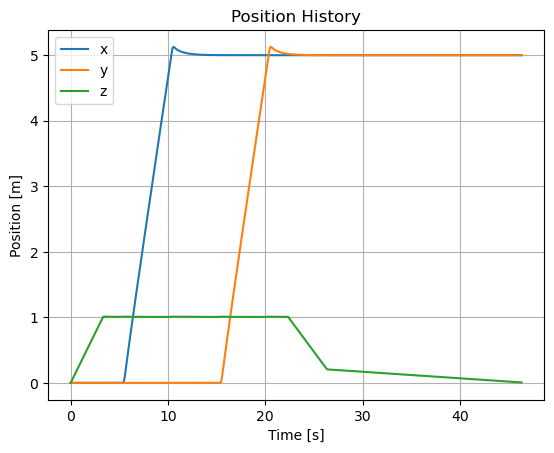

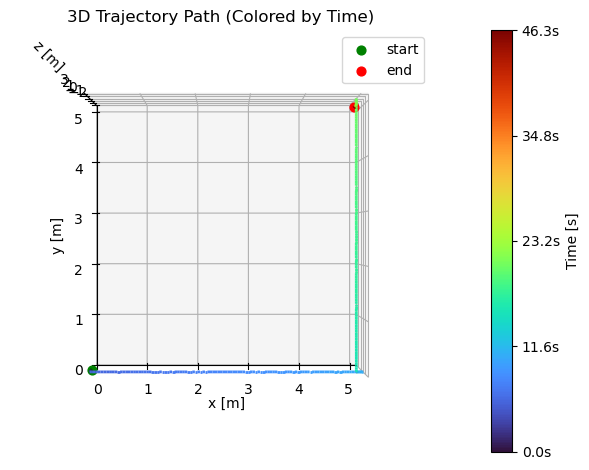

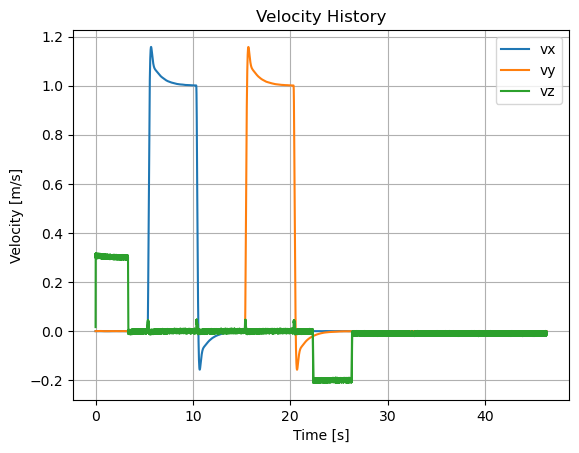

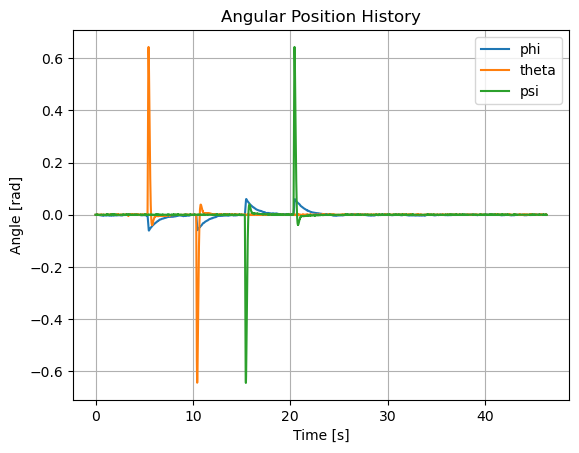

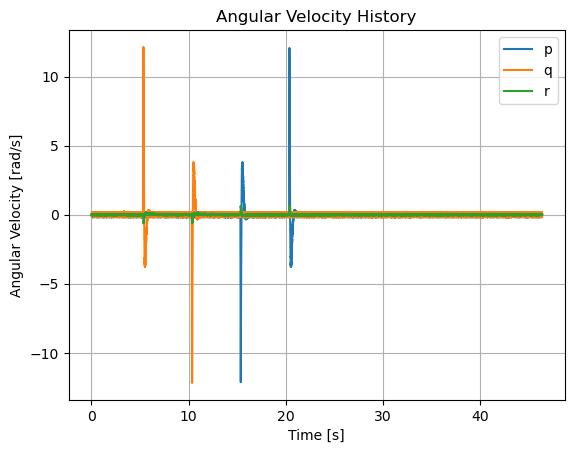

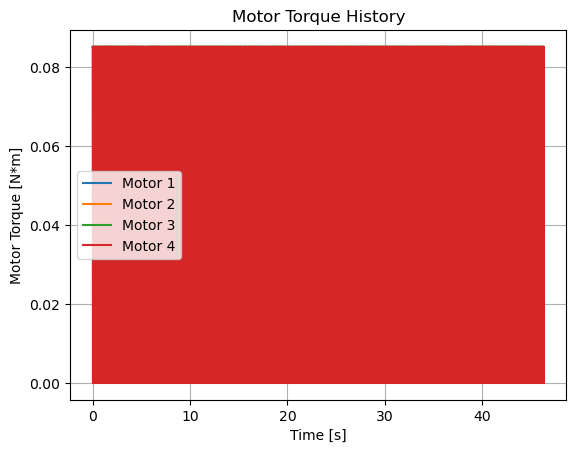

In [21]:
controller.plot_all()